In [1]:
# AWS CLI 설치
!pip install awscli

  Using cached docutils-0.19-py3-none-any.whl.metadata (2.7 kB)
Using cached docutils-0.19-py3-none-any.whl (570 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
# 터미널에서 아래 명령어를 입력했을 때 버전이 제대로 나오면 설치 완료된 것입니다.
!aws --version

aws-cli/1.44.68 Python/3.12.13 Linux/6.6.113+ botocore/1.42.78


In [4]:
# AWS 환경 설정 적용
!aws configure set aws_access_key_id {AWS_ACCESS_KEY}
!aws configure set aws_secret_access_key {AWS_SECRET_KEY}
!aws configure set default.region {REGION}

print(f"✅{TEAM_NAME}의 AWS 환경 설정이 완료되었습니다!")

✅team4의 AWS 환경 설정이 완료되었습니다!


***

데이터 불러오기

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import fbeta_score, precision_recall_curve, auc, recall_score, precision_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [6]:
# train, test 데이터 각각 불러오기
df_train = pd.read_parquet("s3://epoch-mini-project-5th/Silver/real/user/train/train.parquet")
df_test = pd.read_parquet("s3://epoch-mini-project-5th/Silver/real/user/test/test.parquet")

## 데이터 분할

stratified split으로 원본 데이터의 클래스(정답) 비율을 그대로 유지하면서 나눈다.

파산 비율인 3% 유지.

In [7]:
# ID 제거 및 모든 변수 포함
X = df_train.drop(columns=['ID', 'Bankrupt?'])
y = df_train['Bankrupt?']

# Stratified Holdout Split (20%는 최종 검증용으로)
X_train_sub, X_valid_holdout, y_train_sub, y_valid_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train Sub Size: {X_train_sub.shape}, Holdout Size: {X_valid_holdout.shape}")
print(f"Train Sub Positive: {y_train_sub.sum()}, Holdout Positive: {y_valid_holdout.sum()}")

Train Sub Size: (3818, 95), Holdout Size: (955, 95)
Train Sub Positive: 123, Holdout Positive: 31


***

## 전처리

* Clipping으로 이상치 제거: 상위 1%, 하위 99% 넘어가는 값들은 각각 1%와 99%로 강제로 보정.
* Skewness: 왜도가 기준치 1보다 크고, 모든 값이 0 이상인 변수에 대해 로그 변환
* Fit vs Transform 분리: 훈련 데이터에서 상/하위 1% 찾아서 저장. 검증 데이터의 값을 기준으로 하면 leakage니까

In [8]:
class FinancePreprocessor:
    def __init__(self, flag_cols=None, clip_lower=0.01, clip_upper=0.99, skew_threshold=1.0):
        self.flag_cols = flag_cols if flag_cols is not None else []
        self.clip_lower = clip_lower
        self.clip_upper = clip_upper
        self.skew_threshold = skew_threshold
        
        self.num_cols_ = None
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.skewed_cols_ = None
        self.feature_order_ = None

    def fit(self, X: pd.DataFrame):
        X = X.copy()
        self.feature_order_ = X.columns.tolist()

        # flag 제외한 일반 수치형 변수
        self.num_cols_ = [c for c in X.columns if c not in self.flag_cols]

        X_num = X[self.num_cols_].copy()

        # train_sub 기준 clipping 경계 저장
        self.lower_bounds_ = X_num.quantile(self.clip_lower)
        self.upper_bounds_ = X_num.quantile(self.clip_upper)

        # clipping 후 왜도 계산
        X_clipped = X_num.clip(
            lower=self.lower_bounds_,
            upper=self.upper_bounds_,
            axis=1
        )

        skewness = X_clipped.skew(numeric_only=True)

        # log1p는 음수 있으면 곤란하므로, "clipping 후에도 모든 값이 0 이상"인 변수만 적용
        candidate_cols = skewness[skewness > self.skew_threshold].index.tolist()
        self.skewed_cols_ = [c for c in candidate_cols if (X_clipped[c] >= 0).all()]

        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()

        # fit 때 본 컬럼 순서로 정렬
        X = X[self.feature_order_].copy()

        # 일반 수치형 변수만 처리
        X_num = X[self.num_cols_].copy()

        # train_sub에서 구한 기준으로 clip
        X_num = X_num.clip(
            lower=self.lower_bounds_,
            upper=self.upper_bounds_,
            axis=1
        )

        # 왜도 큰 양수 변수만 log1p
        if len(self.skewed_cols_) > 0:
            X_num[self.skewed_cols_] = np.log1p(X_num[self.skewed_cols_])

        # 원본에 반영
        X_out = X.copy()
        X_out[self.num_cols_] = X_num

        return X_out

    def fit_transform(self, X: pd.DataFrame):
        return self.fit(X).transform(X)

In [9]:
flag_cols = ['Liability-Assets Flag', 'Net Income Flag']

preprocessor = FinancePreprocessor(
    flag_cols=flag_cols,
    clip_lower=0.01,
    clip_upper=0.99,
    skew_threshold=1.0)

X_train_sub_prep = preprocessor.fit_transform(X_train_sub)
X_valid_holdout_prep = preprocessor.transform(X_valid_holdout)

print("원본 shape:", X_train_sub.shape, X_valid_holdout.shape)
print("전처리 후 shape:", X_train_sub_prep.shape, X_valid_holdout_prep.shape)
print("log 적용 변수 수:", len(preprocessor.skewed_cols_))
print("예시 log 적용 변수:", preprocessor.skewed_cols_[:10])

원본 shape: (3818, 95) (955, 95)
전처리 후 shape: (3818, 95) (955, 95)
log 적용 변수 수: 58
예시 log 적용 변수: [' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)']


## 모델 성능 비교

logistic, RandomForest, XGBoost, LightGBM을 동시에 돌려서 성능 확인

* StrarifiedKFold: 데이터를 5개 덩어리(Fold)로 나눈 뒤, 4개로 학습하고 1개로 검증
* OOF(Out-Of-Fold): 모델이 학습할 때 보지 못했던 데이터들에 대한 예측값들을 모은다. 이렇게 하면 데이터 전체에 대해 "한 번도 본 적 없는 데이터인 척" 성능 측정 가능
* PR curve를 활용: F2-Score가 최대가 되는 threshold를 찾는다. 보통은 확률이 0.5가 넘으면 파산이라고 보지만, 파산 기업은 워낙 적어서 모델이 확률을 낮게 줄 때가 많다. 그래서 0.1이나 0.2처럼 낮은 확률이라도 파산의 징후가 보이면 1로 분류하도록 결정의 기준점(threshold)을 유연하게 조정. F1이 아닌 F2를 씀으로써, "정상을 파산이라고 오해(Precision 손해)하더라도, 진짜 파산을 놓치는 일(Recall 강조)은 없도록" 최적화

In [10]:
# =========================
# OOF 기반 모델 비교 함수
# =========================
def evaluate_models_oof(X, y, random_state=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    # 전체 train_sub 기준 imbalance ratio
    # RandomForest와 Logistic 모델에서 balanced로 가중치 조절
    # XGBoost와 LightGBM 모델에게 1번 데이터의 중요도를 32배 높게 책정하여 학습하도록 명령
    pos = y.sum()
    neg = len(y) - pos
    scale_pos_weight = neg / pos

    models = {
        'Logistic': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                random_state=random_state
            ))
        ]),
        'RandomForest': RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            n_jobs=-1,
            random_state=random_state
        ),
        'XGBoost': XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=random_state,
            tree_method='hist',
            n_jobs=-1
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            importance_type='gain',
            random_state=random_state,
            verbose=-1,
            n_jobs=-1
        )
    }

    results = []

    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")
        oof_probs = np.zeros(len(X))

        # 80%의 데이터로 모델을 학습시키고, 학습에 전혀 참여하지 않은 나머지 20%의 데이터에 대해서만 예측 확률을 뽑아 oof_probs에 저장
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            X_tr = X.iloc[train_idx]
            X_va = X.iloc[val_idx]
            y_tr = y.iloc[train_idx]
            y_va = y.iloc[val_idx]

            model.fit(X_tr, y_tr)
            oof_probs[val_idx] = model.predict_proba(X_va)[:, 1]

        # PR curve 기반 threshold 탐색
        # precision_recall_curve를 활용해 F2-Score가 최대가 되는 threshold 찾기
        precisions, recalls, thresholds = precision_recall_curve(y, oof_probs)

        # thresholds 길이는 precisions/recalls보다 1 짧음
        f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (
            4 * precisions[:-1] + recalls[:-1] + 1e-8
        )

        best_idx = np.argmax(f2_scores)
        best_thresh = thresholds[best_idx]
        best_f2 = f2_scores[best_idx]

        final_preds = (oof_probs >= best_thresh).astype(int)

        # 각 모델의 성적표 만들기
        results.append({
            'Model': model_name,
            'OOF F2': best_f2,
            'AP': average_precision_score(y, oof_probs),
            'ROC-AUC': roc_auc_score(y, oof_probs),
            'Precision': precision_score(y, final_preds, zero_division=0),
            'Recall': recall_score(y, final_preds, zero_division=0),
            'Threshold': best_thresh,
            'Pred_Positive_Rate': final_preds.mean()
        })

    results_df = pd.DataFrame(results).sort_values(by='OOF F2', ascending=False).reset_index(drop=True)
    return results_df

In [11]:
# =========================
# 실행
# =========================
comparison_df = evaluate_models_oof(X_train_sub_prep, y_train_sub)

print("\n=== Baseline OOF Comparison ===")
print(comparison_df)


Evaluating Logistic...

Evaluating RandomForest...

Evaluating XGBoost...

Evaluating LightGBM...

=== Baseline OOF Comparison ===
          Model    OOF F2        AP   ROC-AUC  Precision    Recall  Threshold  \
0  RandomForest  0.569536  0.400276  0.939269   0.326996  0.699187   0.142866   
1      LightGBM  0.561661  0.407703  0.934229   0.281346  0.747967   0.000078   
2       XGBoost  0.556328  0.416473  0.932244   0.352423  0.650407   0.076699   
3      Logistic  0.537709  0.353330  0.915238   0.343750  0.626016   0.859921   

   Pred_Positive_Rate  
0            0.068884  
1            0.085647  
2            0.059455  
3            0.058669  


* OOF-F2: Recall에 2배 가중치를 준 점수
* AP: PR-Curve 곡선 아래의 면적
* ROC-AUC
* Precision: 정밀도. 파산이라고 예측한 기업 중 실제로 파산한 기업은 몇 개인가?
* Recall: 재현율. 실제 파산한 기업 중 얼마나 찾아냈는가?
* Threshold: 예측 확률이 몇 이상일 때 파산이라고 결론질 것인지에 대한 기준
* Pred_Positive_Rate: 전체 데이터 중 모델이 몇%를 파산이라고 예측했는가?

In [15]:
import matplotlib.pyplot as plt

def plot_model_comparison(results_df):
    plt.figure(figsize=(8,5))
    plt.bar(results_df['Model'], results_df['OOF F2'])
    plt.title('Model Comparison (OOF F2 Score)')
    plt.xlabel('Model')
    plt.ylabel('F2 Score')
    plt.grid(axis='y')
    plt.show()

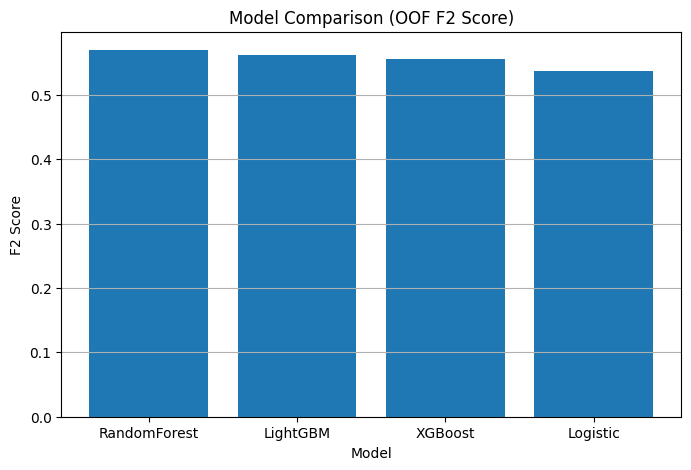

In [16]:
plot_model_comparison(comparison_df)

## 변수 선택

변수 중요도를 추출하고, 그 중요도 순서대로 변수 개수를 조절해가면서 최적의 조합을 찾는다

In [12]:
# =========================
# 중요도 추출 함수
# 앞에서 성능이 괜찮게 나타났던 RF와 XGBoost 모델을 전체 데이터로 학습한 뒤, 어떤 변수가 예측에 가장 기여했는지 정렬한 표를 만든다.
# =========================
def get_feature_importance(model_name, X, y, random_state=42):
    pos = y.sum()
    neg = len(y) - pos
    scale_pos_weight = neg / pos

    if model_name == 'RandomForest':
        model = RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            n_jobs=-1,
            random_state=random_state
        )
    elif model_name == 'XGBoost':
        model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=random_state,
            tree_method='hist',
            n_jobs=-1
        )
    else:
        raise ValueError("model_name must be 'RandomForest' or 'XGBoost'")

    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    importance_df = pd.DataFrame({
        'Feature': importances.index,
        'Importance': importances.values
    })
    return importance_df


# =========================
# OOF 평가 함수
# 앞에서 만든 중요도 표를 기반으로 변수 개수를 바꿔가면서 모델을 테스트한다.
# 계산된 여러 기준 중에서 F2-score가 가장 높게 나오는 지점을 잡아낸다.
# =========================
def evaluate_single_model_oof(model_name, X, y, random_state=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    pos = y.sum()
    neg = len(y) - pos
    scale_pos_weight = neg / pos

    if model_name == 'RandomForest':
        model = RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            n_jobs=-1,
            random_state=random_state
        )
    elif model_name == 'XGBoost':
        model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=random_state,
            tree_method='hist',
            n_jobs=-1
        )
    else:
        raise ValueError("model_name must be 'RandomForest' or 'XGBoost'")

    oof_probs = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[train_idx]
        X_va = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        model.fit(X_tr, y_tr)
        oof_probs[val_idx] = model.predict_proba(X_va)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y, oof_probs)

    f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (
        4 * precisions[:-1] + recalls[:-1] + 1e-8
    )

    best_idx = np.argmax(f2_scores)
    best_thresh = thresholds[best_idx]
    best_f2 = f2_scores[best_idx]

    final_preds = (oof_probs >= best_thresh).astype(int)

    result = {
        'Model': model_name,
        'n_features': X.shape[1],
        'OOF F2': best_f2,
        'AP': average_precision_score(y, oof_probs),
        'ROC-AUC': roc_auc_score(y, oof_probs),
        'Precision': precision_score(y, final_preds, zero_division=0),
        'Recall': recall_score(y, final_preds, zero_division=0),
        'Threshold': best_thresh,
        'Pred_Positive_Rate': final_preds.mean()
    }

    return result, oof_probs


# =========================
# top-k 비교 함수
# 앞에서 얻은 변수 중요도 리스트를 10등, 20등,.. 개수를 10개씩 늘려가면서 OOF F2 점수를 확인한다.
# =========================
def compare_topk_features(model_name, X, y, topk_list=None, random_state=42):
    if topk_list is None:
        topk_list = [10, 20, 30, 40, 50, X.shape[1]]

    # 전체 변수 수보다 큰 값 제거
    topk_list = [k for k in topk_list if k <= X.shape[1]]

    importance_df = get_feature_importance(model_name, X, y, random_state=random_state)

    results = []

    for k in topk_list:
        selected_features = importance_df['Feature'].head(k).tolist()
        X_k = X[selected_features].copy()

        print(f"Evaluating {model_name} with top-{k} features...")
        result, _ = evaluate_single_model_oof(model_name, X_k, y, random_state=random_state)
        results.append(result)

    results_df = pd.DataFrame(results).sort_values(by='OOF F2', ascending=False).reset_index(drop=True)
    return results_df, importance_df

In [13]:
# =========================
# RF / XGB 각각 앞의 함수들 실행
# =========================
topk_candidates = [10, 20, 30, 40, 50, X_train_sub_prep.shape[1]]

rf_topk_results, rf_importance_df = compare_topk_features(
    model_name='RandomForest',
    X=X_train_sub_prep,
    y=y_train_sub,
    topk_list=topk_candidates,
    random_state=42
)

xgb_topk_results, xgb_importance_df = compare_topk_features(
    model_name='XGBoost',
    X=X_train_sub_prep,
    y=y_train_sub,
    topk_list=topk_candidates,
    random_state=42
)

print("\n=== RandomForest Top-k Comparison ===")
print(rf_topk_results)

print("\n=== XGBoost Top-k Comparison ===")
print(xgb_topk_results)

print("\n=== RandomForest Top 20 Important Features ===")
print(rf_importance_df.head(20))

print("\n=== XGBoost Top 20 Important Features ===")
print(xgb_importance_df.head(20))

Evaluating RandomForest with top-10 features...
Evaluating RandomForest with top-20 features...
Evaluating RandomForest with top-30 features...
Evaluating RandomForest with top-40 features...
Evaluating RandomForest with top-50 features...
Evaluating RandomForest with top-95 features...
Evaluating XGBoost with top-10 features...
Evaluating XGBoost with top-20 features...
Evaluating XGBoost with top-30 features...
Evaluating XGBoost with top-40 features...
Evaluating XGBoost with top-50 features...
Evaluating XGBoost with top-95 features...

=== RandomForest Top-k Comparison ===
          Model  n_features    OOF F2        AP   ROC-AUC  Precision  \
0  RandomForest          40  0.597015  0.420189  0.945436   0.307692   
1  RandomForest          30  0.590062  0.437977  0.942444   0.303514   
2  RandomForest          50  0.587071  0.426775  0.940044   0.334586   
3  RandomForest          20  0.576230  0.433733  0.943970   0.281525   
4  RandomForest          95  0.565584  0.400881  0.9407

상위 40개 변수 사용했을 때 가장 좋은 성능 확인.

이를 기반으로 하이퍼파라미터 최적화

In [17]:
# =========================
# top-40 feature 선택
# 앞으로 40개 변수만 사용해서 학습한다.
# =========================
top_k = 40
selected_features = rf_importance_df['Feature'].head(top_k).tolist()

X_train_rf = X_train_sub_prep[selected_features].copy()


# =========================
# F2 scorer 정의
# =========================
f2_scorer = make_scorer(fbeta_score, beta=2)


# =========================
# 모델 정의
# =========================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


# =========================
# 파라미터 공간 정의
# =========================
param_dist = {
    'n_estimators': [300, 400, 500, 700],
    'max_depth': [None, 6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.8]
}


# =========================
# RandomizedSearch
# =========================
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,
    scoring=f2_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# train set으로 F2 score 점수 확인해보기
rf_search.fit(X_train_rf, y_train_sub)

print("\n=== Best RF Params ===")
print(rf_search.best_params_)

print("\n=== Best CV F2 ===")
print(rf_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

=== Best RF Params ===
{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 6}

=== Best CV F2 ===
0.5865983128924059


앞에서 찾은 하이퍼파라미터로 최적의 threshold 찾기

이미 튜닝 단계에서 5-Fold 교차 검증을 했지만, 전체 데이터에 대한 '예측 확률값'을 모으기 위해 다시 한 번 수행.

데이터를 5개로 나눠 돌아가며 학습하고, 모델이 학습할 때 보지 못했던 데이터에 대한 파산 확률(oof_probs)을 채워 나간다.

In [25]:
# best model 가져오기
best_rf = rf_search.best_estimator_

# top-40 feature 사용
top_k = 40
selected_features = rf_importance_df['Feature'].head(top_k).tolist()
X_train_rf = X_train_sub_prep[selected_features].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros(len(X_train_rf))

for train_idx, val_idx in skf.split(X_train_rf, y_train_sub):
    X_tr = X_train_rf.iloc[train_idx]
    X_va = X_train_rf.iloc[val_idx]
    y_tr = y_train_sub.iloc[train_idx]

    best_rf.fit(X_tr, y_tr)
    oof_probs[val_idx] = best_rf.predict_proba(X_va)[:, 1]


# threshold 탐색
precisions, recalls, thresholds = precision_recall_curve(y_train_sub, oof_probs)

f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (
    4 * precisions[:-1] + recalls[:-1] + 1e-8
)

best_idx = np.argmax(f2_scores)
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

final_preds = (oof_probs >= best_thresh).astype(int)

print("\n=== Tuned RF OOF Results ===")
print("F2:", best_f2)
print("Threshold:", best_thresh)
print("Precision:", precision_score(y_train_sub, final_preds))
print("Recall:", recall_score(y_train_sub, final_preds))
print("Pred Positive Rate:", final_preds.mean())


=== Tuned RF OOF Results ===
F2: 0.5977011463539438
Threshold: 0.302120593277222
Precision: 0.2751322751322751
Recall: 0.8455284552845529
Pred Positive Rate: 0.09900471451021477


In [26]:
print("\n=== Threshold Sweep ===")

for t in np.linspace(0.1, 0.6, 10):
    preds = (oof_probs >= t).astype(int)
    
    f2 = fbeta_score(y_train_sub, preds, beta=2)
    prec = precision_score(y_train_sub, preds, zero_division=0)
    rec = recall_score(y_train_sub, preds, zero_division=0)
    rate = preds.mean()
    
    print(f"t={t:.2f} | F2={f2:.4f} | P={prec:.3f} | R={rec:.3f} | PosRate={rate:.3f}")


=== Threshold Sweep ===
t=0.10 | F2=0.4415 | P=0.143 | R=0.927 | PosRate=0.209
t=0.16 | F2=0.4950 | P=0.178 | R=0.894 | PosRate=0.162
t=0.21 | F2=0.5388 | P=0.214 | R=0.870 | PosRate=0.131
t=0.27 | F2=0.5733 | P=0.251 | R=0.846 | PosRate=0.109
t=0.32 | F2=0.5875 | P=0.279 | R=0.813 | PosRate=0.094
t=0.38 | F2=0.5714 | P=0.294 | R=0.748 | PosRate=0.082
t=0.43 | F2=0.5628 | P=0.316 | R=0.699 | PosRate=0.071
t=0.49 | F2=0.5556 | P=0.342 | R=0.659 | PosRate=0.062
t=0.54 | F2=0.5398 | P=0.358 | R=0.618 | PosRate=0.056
t=0.60 | F2=0.5336 | P=0.380 | R=0.593 | PosRate=0.050


추가로 임계값 조절해가면서 스코어 확인

t_low (공격형): 0.30
t_mid (균형형): 0.38
t_high (보수형): 0.45

*** 

## 최종 스코어 확인

훈련데이터로 최종 모델 학습시키고, holdout data로 문제 풀어보기

In [27]:
# top-40 feature
selected_features = rf_importance_df['Feature'].head(40).tolist()

X_train_rf = X_train_sub_prep[selected_features].copy()
X_holdout_rf = X_valid_holdout_prep[selected_features].copy()

best_rf = rf_search.best_estimator_
best_rf.fit(X_train_rf, y_train_sub)

holdout_probs = best_rf.predict_proba(X_holdout_rf)[:, 1]

모델이 예측한 확률을 바탕으로 실제 임계값 몇이 좋은지 시뮬레이션해서 최적값 찾기

In [28]:
# 예시 threshold 후보
threshold_list = [0.30, 0.32, 0.35, 0.38, 0.40, 0.43, 0.45, 0.49, 0.50, 0.55, 0.60, 0.65]

results = []

for t in threshold_list:
    preds = (holdout_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_valid_holdout, preds).ravel()

    results.append({
        'threshold': t,
        'F2': fbeta_score(y_valid_holdout, preds, beta=2, zero_division=0),
        'precision': precision_score(y_valid_holdout, preds, zero_division=0),
        'recall': recall_score(y_valid_holdout, preds, zero_division=0),
        'pred_positive_rate': preds.mean(),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

threshold_results = pd.DataFrame(results).sort_values(
    by=['F2', 'precision'], ascending=[False, False]
).reset_index(drop=True)

print(threshold_results)

    threshold        F2  precision    recall  pred_positive_rate  TP  FP  FN  \
0        0.38  0.595855   0.333333  0.741935            0.072251  23  46   8   
1        0.40  0.595855   0.333333  0.741935            0.072251  23  46   8   
2        0.45  0.578947   0.333333  0.709677            0.069110  22  44   9   
3        0.43  0.575916   0.328358  0.709677            0.070157  22  45   9   
4        0.65  0.575758   0.463415  0.612903            0.042932  19  22  12   
5        0.35  0.572139   0.298701  0.741935            0.080628  23  54   8   
6        0.30  0.568720   0.275862  0.774194            0.091099  24  63   7   
7        0.32  0.563725   0.287500  0.741935            0.083770  23  57   8   
8        0.60  0.558824   0.413043  0.612903            0.048168  19  27  12   
9        0.55  0.545977   0.380000  0.612903            0.052356  19  31  12   
10       0.50  0.524862   0.333333  0.612903            0.059686  19  38  12   
11       0.49  0.521978   0.327586  0.61

0.4로 임계값 결정!했다가

실제 테스트에서는 임계값 0.49가 제일 성능 좋아서 변경

In [29]:
# =========================
# 최종 설정
# =========================
FINAL_THRESHOLD = 0.49
TOP_K = 40

# holdout 보기 전에 정한 top-40 변수 사용
selected_features = rf_importance_df['Feature'].head(TOP_K).tolist()

# 실제 flag 변수명으로 맞춰줘
flag_cols = [
    'Liability-Assets Flag',
    'Net Income Flag' 
]

# =========================
# train / test 원본 분리
# =========================
X_full_train = df_train.drop(columns=['ID', 'Bankrupt?']).copy()
y_full_train = df_train['Bankrupt?'].copy()

X_test = df_test.drop(columns=['ID']).copy()
test_ids = df_test['ID'].copy()

print("Full train shape:", X_full_train.shape)
print("Test shape:", X_test.shape)
print("Positive rate in full train:", y_full_train.mean())

# =========================
# 전처리: full train에 fit, test에 transform
# =========================
final_preprocessor = FinancePreprocessor(
    flag_cols=flag_cols,
    clip_lower=0.01,
    clip_upper=0.99,
    skew_threshold=1.0
)

X_full_train_prep = final_preprocessor.fit_transform(X_full_train)
X_test_prep = final_preprocessor.transform(X_test)

print("Preprocessed full train shape:", X_full_train_prep.shape)
print("Preprocessed test shape:", X_test_prep.shape)
print("Number of log-transformed columns:", len(final_preprocessor.skewed_cols_))

# =========================
# 선택된 feature만 사용
# =========================
X_full_train_final = X_full_train_prep[selected_features].copy()
X_test_final = X_test_prep[selected_features].copy()

print("Final train feature shape:", X_full_train_final.shape)
print("Final test feature shape:", X_test_final.shape)

# =========================
# 최종 RF 모델 정의
# (튜닝 결과 고정)
# =========================
final_rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=1,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# =========================
# 전체 train으로 재학습
# =========================
final_rf.fit(X_full_train_final, y_full_train)

# =========================
# test 확률 예측 + threshold 적용
# =========================
test_probs = final_rf.predict_proba(X_test_final)[:, 1]
test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)

print("Test predicted positive rate:", test_preds.mean())

# =========================
# 제출 파일 생성
#    컬럼명은 대회 제출 형식에 맞게 수정 필요
# =========================
submission = pd.DataFrame({
    'ID': test_ids,
    'Bankrupt?': test_preds
})

Full train shape: (4773, 95)
Test shape: (2046, 95)
Positive rate in full train: 0.03226482296249738
Preprocessed full train shape: (4773, 95)
Preprocessed test shape: (2046, 95)
Number of log-transformed columns: 58
Final train feature shape: (4773, 40)
Final test feature shape: (2046, 40)
Test predicted positive rate: 0.06549364613880743


***

## 제출용 파일 생성

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
submission_path = '/content/drive/MyDrive/result.csv'

submission.to_csv(submission_path, index=False)

print(f"Saved to Google Drive: {submission_path}")

Saved to Google Drive: /content/drive/MyDrive/result.csv


***